In [113]:
import numpy as np
import matplotlib.pyplot as plt
import nseabundance as nse
import ODESolve_slow as ODE
import weakrates as weak
import expansion as ex
import derivatives as der
from constants import dmnp, zeta3, hbar



In [115]:
a0 = 0.1    
T0 = 10
t0 = 0
eta0 = (6.1e-10)*(11/4)
Yp0 = (1+(weak.Npntot(T0,a0))/(weak.Nnptot(T0,a0)) )**(-1)
Yn0 = 1-Yp0

y0 = der.depvar(T0, t0, eta0, nse.nse(T0, eta0, Yp0, Yn0))
p=None
dx0=0.001

N_step = 1000
dN = 2
x_final = 100

a, y, dx, done = ODE.ODEOneRun(a0, y0, dx0, p, N_step, dN, x_final)
print(done)

True


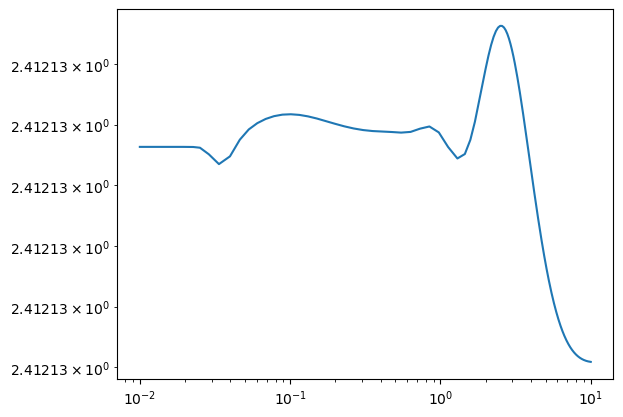

In [116]:
plt.figure()
Tcm=1/a
T=y[:,0]
sthacubed=np.zeros(len(a))
for i in range(len(a)):
    sthacubed[i]=ex.sth(y[i,0])*a[i]**3



plt.loglog(Tcm, sthacubed)


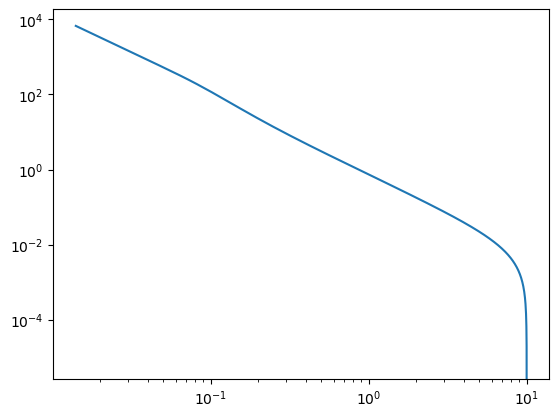

In [117]:
plt.figure()
T=y[:,0]
t=y[:,1]*hbar

plt.loglog(T, t)

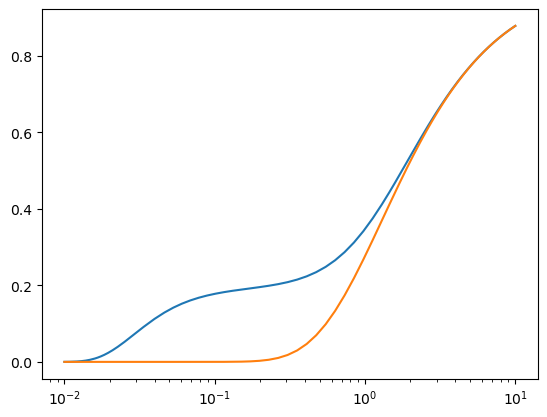

In [125]:
Tcm=1/a
Yn = np.zeros(len(a))
Yp = np.zeros(len(a))
for i in range(len(a)):
    Yn[i] = y[i,4]
    Yp[i] = y[i,3]
plt.semilogx(Tcm,Yn/Yp)

plt.semilogx(Tcm, np.exp((-dmnp)/T))


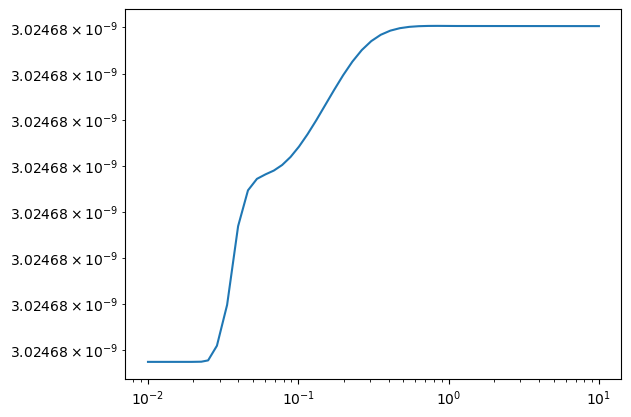

In [127]:
plt.figure()

ngamma=(3/2)*zeta3*y[:,0]**3
plt.loglog(Tcm,y[:,2]*ngamma*a**3)